### Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import normalize
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [3]:
print(torch.cuda.is_available())
print(torch.version.cuda)

True
12.1


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


### Read csv

In [5]:
df = pd.read_csv("ONGC.csv")

In [6]:
df.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2000-01-03,ONGC,EQ,207.70,205.0,214.4,205.0,214.0,213.45,209.91,9600,2.015090e+11,NaN,NaN,NaN
1,2000-01-04,ONGC,EQ,213.45,201.5,209.7,201.0,209.0,206.55,206.26,17900,3.692030e+11,NaN,NaN,NaN
2,2000-01-05,ONGC,EQ,206.55,201.0,223.1,200.5,223.1,223.10,215.46,27000,5.817490e+11,NaN,NaN,NaN
3,2000-01-06,ONGC,EQ,223.10,234.0,234.9,217.6,217.6,219.30,223.42,35600,7.953680e+11,NaN,NaN,NaN
4,2000-01-07,ONGC,EQ,219.30,223.0,223.0,213.0,215.7,215.75,215.19,11400,2.453145e+11,NaN,NaN,NaN


In [7]:
df.shape

(5306, 15)

In [8]:
df['Date'] = pd.to_datetime(df['Date'], errors="coerce")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Invalid dates (NaT): {df['Date'].isnull().sum()}")

df = df.sort_values('Date').reset_index(drop=True)

Date range: 2000-01-03 00:00:00 to 2021-04-30 00:00:00
Invalid dates (NaT): 0


### Remove Duplicates

In [9]:
print("Check and Remove Duplicates")
dups = df.duplicated().sum()
print(f"  Duplicate rows found: {dups}")
if dups > 0:
    df = df.drop_duplicates()
    print(f"    Duplicates removed. New shape: {df.shape}")

Check and Remove Duplicates
  Duplicate rows found: 0


### Defining Numeric DataFrame

In [10]:
numeric_df = df.iloc[:,3:-1]
print("Shape:", numeric_df.shape)
print("\nColumns:", numeric_df.columns.tolist())
print("\nFirst 5 rows:")
numeric_df.head()

Shape: (5306, 11)

Columns: ['Prev Close', 'Open', 'High', 'Low', 'Last', 'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume']

First 5 rows:


,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume
0,207.70,205.0,214.4,205.0,214.0,213.45,209.91,9600,2.015090e+11,NaN,NaN
1,213.45,201.5,209.7,201.0,209.0,206.55,206.26,17900,3.692030e+11,NaN,NaN
2,206.55,201.0,223.1,200.5,223.1,223.10,215.46,27000,5.817490e+11,NaN,NaN
3,223.10,234.0,234.9,217.6,217.6,219.30,223.42,35600,7.953680e+11,NaN,NaN
4,219.30,223.0,223.0,213.0,215.7,215.75,215.19,11400,2.453145e+11,NaN,NaN


### Handling Missing Values

In [11]:
print("Missing values:")
print(numeric_df.isnull().sum())

numeric_df = numeric_df.apply(pd.to_numeric,errors='coerce')
numeric_df = numeric_df.interpolate(method="linear", limit_direction="both")
numeric_df = numeric_df.ffill().bfill()

print("\nMissing values after interpolation:")
print(numeric_df.isnull().sum())

Missing values:
Prev Close               0
Open                     0
High                     0
Low                      0
Last                     0
Close                    0
VWAP                     0
Volume                   0
Turnover                 0
Trades                2850
Deliverable Volume     509
dtype: int64

Missing values after interpolation:
Prev Close            0
Open                  0
High                  0
Low                   0
Last                  0
Close                 0
VWAP                  0
Volume                0
Turnover              0
Trades                0
Deliverable Volume    0
dtype: int64


### Numeric DataFrame after cleaning

In [12]:
print("Shape:", numeric_df.shape)
print("\nColumns:", numeric_df.columns.tolist())
print("\nFirst 5 rows:")
numeric_df.head()

Shape: (5306, 11)

Columns: ['Prev Close', 'Open', 'High', 'Low', 'Last', 'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume']

First 5 rows:


,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume
0,207.70,205.0,214.4,205.0,214.0,213.45,209.91,9600,2.015090e+11,35221.0,1338.0
1,213.45,201.5,209.7,201.0,209.0,206.55,206.26,17900,3.692030e+11,35221.0,1338.0
2,206.55,201.0,223.1,200.5,223.1,223.10,215.46,27000,5.817490e+11,35221.0,1338.0
3,223.10,234.0,234.9,217.6,217.6,219.30,223.42,35600,7.953680e+11,35221.0,1338.0
4,219.30,223.0,223.0,213.0,215.7,215.75,215.19,11400,2.453145e+11,35221.0,1338.0


In [13]:
feature_names = numeric_df.columns.tolist()
print("Features used:", feature_names)

data = numeric_df.values   # convert to numpy array
num_features = data.shape[1]

print("Shape:", data.shape)

Features used: ['Prev Close', 'Open', 'High', 'Low', 'Last', 'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume']
Shape: (5306, 11)


### Plotting Features against Date

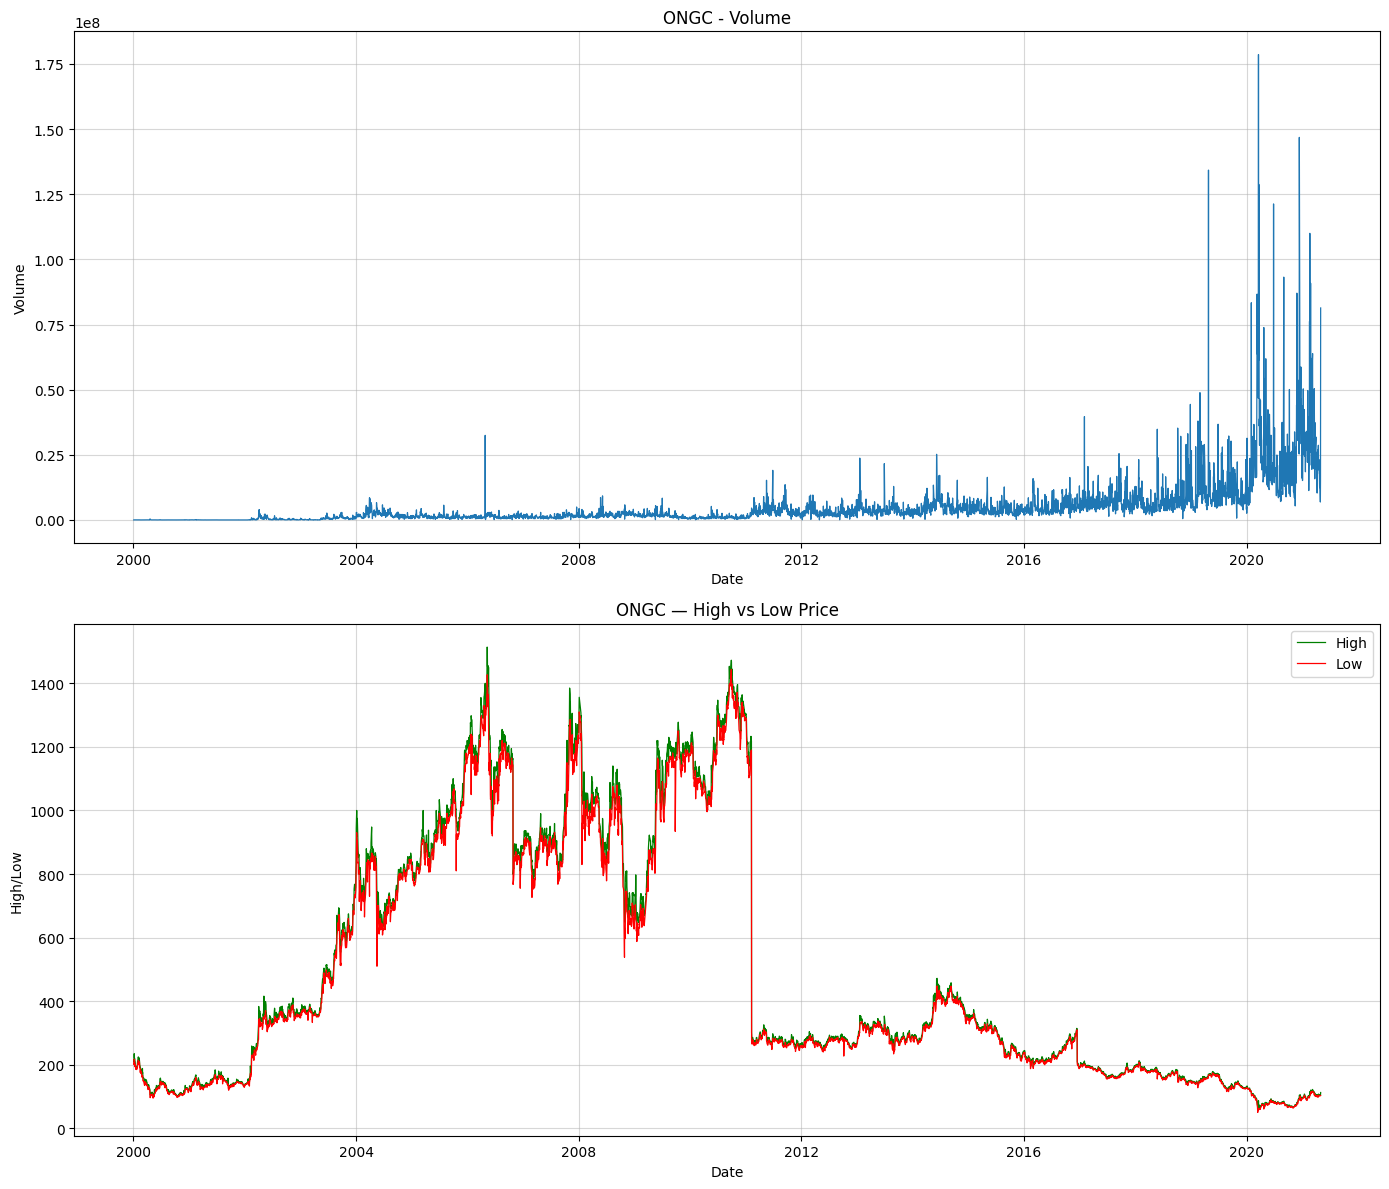

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

df['Date']=pd.to_datetime(df['Date'])


axes[0].plot(df['Date'], numeric_df['Volume'],linewidth=0.9)
axes[0].set_title('ONGC - Volume')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Volume')
axes[0].grid(True, alpha=0.5)


axes[1].plot(df['Date'], numeric_df['High'], color='green', linewidth=0.9, label='High')
axes[1].plot(df['Date'], numeric_df['Low'], color='red', linewidth=0.9, label='Low')
axes[1].set_title('ONGC — High vs Low Price', fontsize=12)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('High/Low')
axes[1].legend()
axes[1].grid(True, alpha=0.5)



plt.tight_layout()
plt.show()

In [15]:
data = numeric_df.values.astype(np.float32)
print("Data shape:", data.shape)

Data shape: (5306, 11)


### Train Test Validation Split

In [16]:
TRAIN_RATIO = 0.8

split_idx = int(len(data) * TRAIN_RATIO)

train_data_temp = data[:split_idx]
test_data = data[split_idx:]

# split train into train and validation sets (80:20)
val_split_idx = int(len(train_data_temp) * 0.8)

train_data = train_data_temp[:val_split_idx]
val_data = train_data_temp[val_split_idx:]

print("Train Dataset shape: ", train_data.shape)
print("\nValidation Dataset shape: ", val_data.shape)
print("\nTest Dataset shape: ", test_data.shape)

Train Dataset shape:  (3395, 11)

Validation Dataset shape:  (849, 11)

Test Dataset shape:  (1062, 11)


### Normalization using 'l2' Normalizer

In [17]:

train_data_norm = normalize(train_data, norm='l2', axis=0)
test_data_norm = normalize(test_data, norm='l2', axis=0)
val_data_norm = normalize(val_data, norm='l2', axis=0)

### Creating time sequence

In [18]:
#input_steps: number of past time steps used as input=10
#output_steps: number of future time steps to predict=5
import numpy as np

INPUT_STEPS = 10
OUTPUT_STEPS = 5
BATCH_SIZE = 4

def create_sequences(data_array, input_steps=INPUT_STEPS, output_steps=OUTPUT_STEPS, overlap=1):
    X, y = [], []
    total_len = len(data_array)

    stride = input_steps - overlap
    if stride <= 0:
        raise ValueError("overlap must be smaller than input_steps")

    for i in range(0, total_len - input_steps - output_steps + 1, stride):
        X.append(data_array[i:i + input_steps])
        y.append(data_array[i + input_steps : i + input_steps + output_steps])

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

In [19]:
X_train, y_train = create_sequences(train_data_norm, INPUT_STEPS, OUTPUT_STEPS, overlap=8)
X_test, y_test = create_sequences(test_data_norm, INPUT_STEPS, OUTPUT_STEPS, overlap=8)
X_val, y_val = create_sequences(val_data_norm, INPUT_STEPS, OUTPUT_STEPS, overlap=8)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)
print("X_val :", X_val.shape, "y_val :", y_val.shape)

X_train: (1691, 10, 11) y_train: (1691, 5, 11)
X_test : (524, 10, 11) y_test : (524, 5, 11)
X_val : (418, 10, 11) y_val : (418, 5, 11)


In [20]:
from torch.utils.data import Dataset
import torch

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [21]:
train_dataset = TimeSeriesDataset(X_train, y_train)
test_dataset = TimeSeriesDataset(X_test, y_test)
val_dataset = TimeSeriesDataset(X_val, y_val)

In [22]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

### Defining LSTM

In [23]:
import torch.nn as nn

class LSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(11, 32, batch_first=True)
        self.fc = nn.Linear(32, 5 * 11)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out.view(-1, 5, 11)

### Instantiating Model

In [24]:
import torch

model = LSTM().to(device)

lr = 0.0001
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion_MSE = nn.MSELoss()
criterion_MAE = nn.L1Loss()

def RMSELoss(y_pred, y_true):
    mse = nn.MSELoss()(y_pred,y_true)
    rmse = torch.sqrt(mse)
    return rmse

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    patience=10
)

### Method for Training 1 epoch

In [25]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    return running_loss / len(loader.dataset)

### Method for evaluation

In [26]:
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            preds = model(X_batch)
            loss = criterion(preds, y_batch)

            running_loss += loss.item() * X_batch.size(0)
            all_preds.append(preds.cpu())
            all_targets.append(y_batch.cpu())

    avg_loss = running_loss / len(loader.dataset)
    all_preds = torch.cat(all_preds, dim=0).numpy()
    all_targets = torch.cat(all_targets, dim=0).numpy()

    return avg_loss, all_preds, all_targets

### Training with Early Stopping

In [27]:
#Training with early stopping based on validation loss
EPOCHS = 100
PATIENCE = 20 
train_losses_MSE = []
val_losses_MSE = []
best_val_loss = float('inf')
epochs_no_improve = 0

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion_MSE, device)
    val_loss, _, _ = evaluate(model, val_loader, criterion_MSE, device)

    train_losses_MSE.append(train_loss)
    val_losses_MSE.append(val_loss)

    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0

        
        torch.save(model.state_dict(), "best_model.pt")
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= PATIENCE:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

Epoch [1/100] | Train Loss: 0.002696 | Val Loss: 0.000472
Epoch [2/100] | Train Loss: 0.000101 | Val Loss: 0.000449
Epoch [3/100] | Train Loss: 0.000097 | Val Loss: 0.000424
Epoch [4/100] | Train Loss: 0.000094 | Val Loss: 0.000411
Epoch [5/100] | Train Loss: 0.000090 | Val Loss: 0.000376
Epoch [6/100] | Train Loss: 0.000085 | Val Loss: 0.000383
Epoch [7/100] | Train Loss: 0.000080 | Val Loss: 0.000368
Epoch [8/100] | Train Loss: 0.000073 | Val Loss: 0.000262
Epoch [9/100] | Train Loss: 0.000066 | Val Loss: 0.000273
Epoch [10/100] | Train Loss: 0.000060 | Val Loss: 0.000224
Epoch [11/100] | Train Loss: 0.000054 | Val Loss: 0.000183
Epoch [12/100] | Train Loss: 0.000050 | Val Loss: 0.000184
Epoch [13/100] | Train Loss: 0.000048 | Val Loss: 0.000179
Epoch [14/100] | Train Loss: 0.000046 | Val Loss: 0.000157
Epoch [15/100] | Train Loss: 0.000045 | Val Loss: 0.000150
Epoch [16/100] | Train Loss: 0.000044 | Val Loss: 0.000149
Epoch [17/100] | Train Loss: 0.000043 | Val Loss: 0.000144
Epoch 

### Test Dataset evaluation

In [28]:

test_loss_MSE, predictions_MSE, targets_MSE = evaluate(model, test_loader, criterion_MSE, device)
print("\nFinal Test Loss:", test_loss_MSE)


Final Test Loss: 0.00013000062803715824


In [29]:
test_loss_RMSE, predictions_RMSE, targets_RMSE = evaluate(model, test_loader, RMSELoss, device)
print("\nFinal Test Loss:", test_loss_RMSE)


Final Test Loss: 0.009150177787790316


In [30]:
test_loss_MAE, predictions_MAE, targets_MAE = evaluate(model, test_loader, criterion_MAE, device)
print("\nFinal Test Loss:", test_loss_MAE)


Final Test Loss: 0.004531993751968648


### Plotting Predicted Values vs Target Values for different Losses 


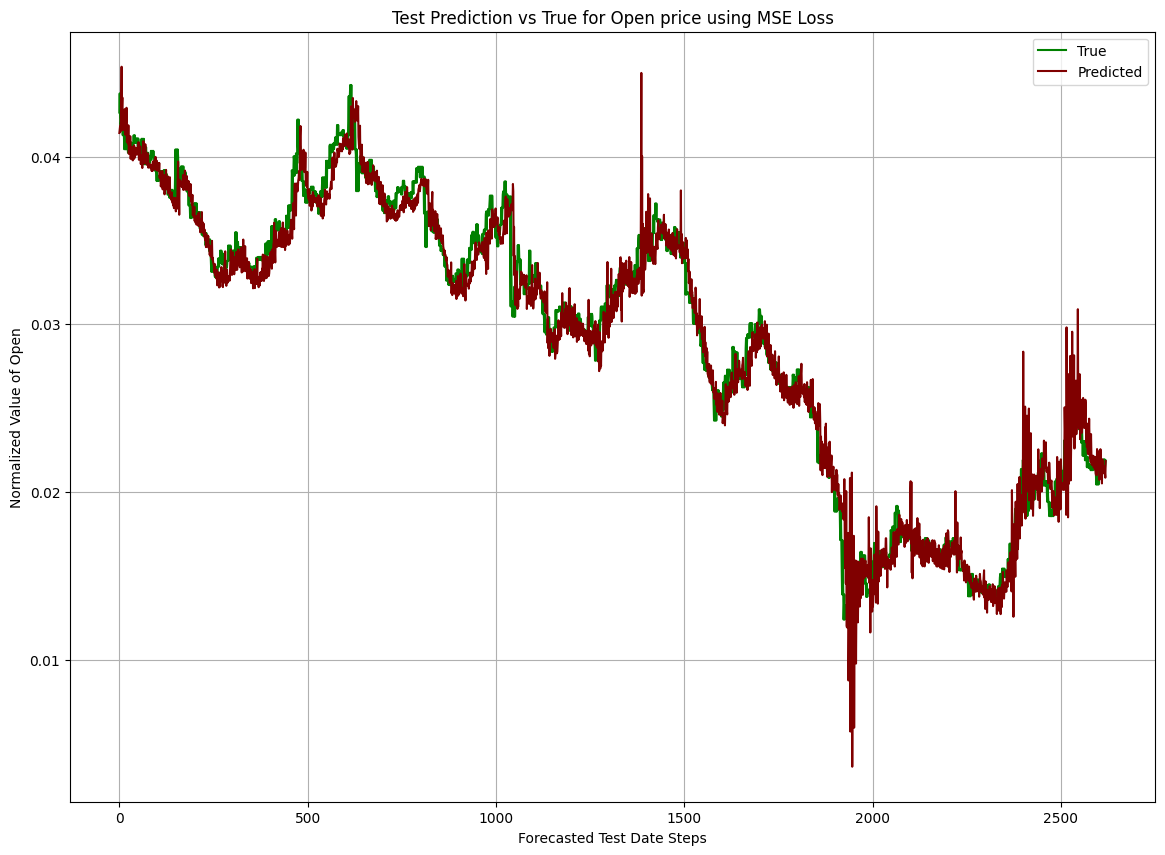

In [31]:
# MSE
PLOT_FEATURE = "Open" 

if PLOT_FEATURE not in feature_names:
    raise ValueError(f"{PLOT_FEATURE} not found. Choose from: {feature_names}")

feature_idx = feature_names.index(PLOT_FEATURE)

pred_feature = predictions_MSE[:, :, feature_idx].reshape(-1)
true_feature = targets_MSE[:, :, feature_idx].reshape(-1)

plt.figure(figsize=(14, 10))
plt.plot(true_feature, color='green', label="True")
plt.plot(pred_feature, color='maroon', label="Predicted")

plt.title(f"Test Prediction vs True for {PLOT_FEATURE} price using MSE Loss")
plt.xlabel("Forecasted Test Date Steps")
plt.ylabel(f"Normalized Value of {PLOT_FEATURE}")

plt.legend()
plt.grid(True)
plt.show()

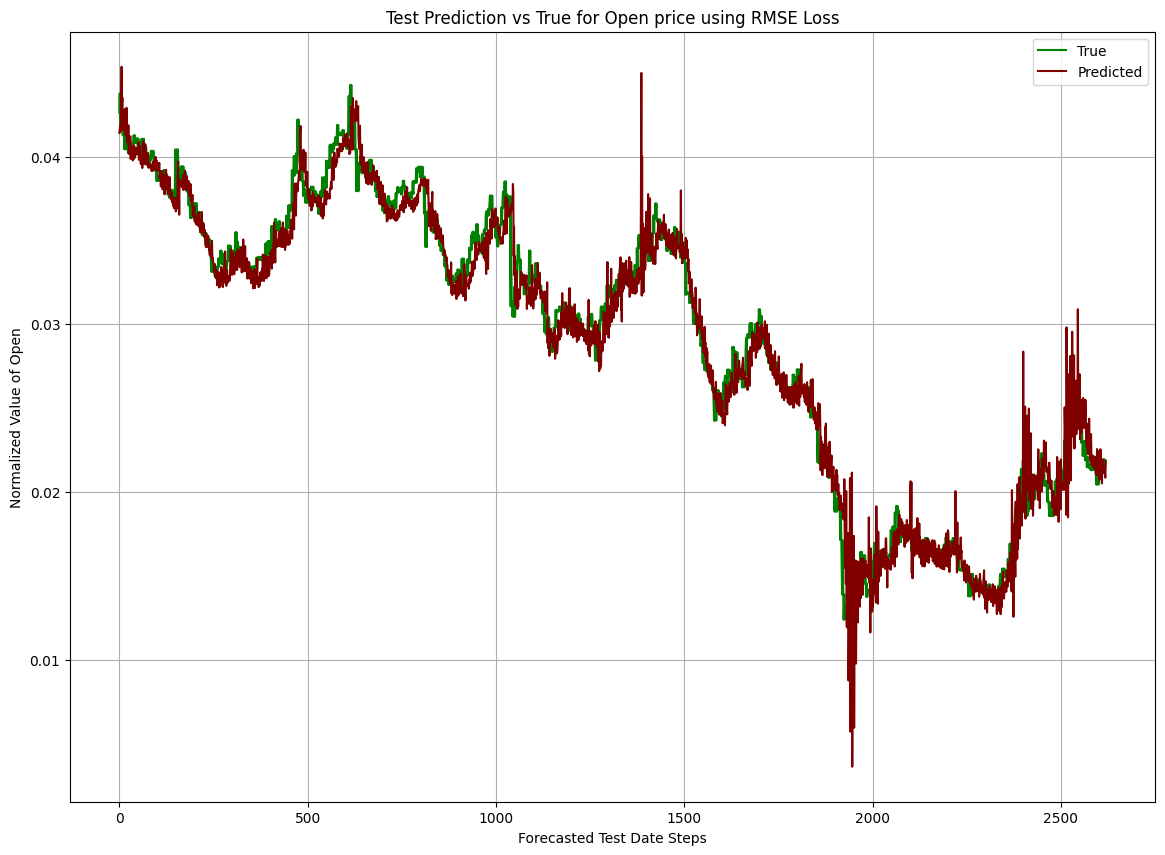

In [32]:
# RMSE
PLOT_FEATURE = "Open" 

if PLOT_FEATURE not in feature_names:
    raise ValueError(f"{PLOT_FEATURE} not found. Choose from: {feature_names}")

feature_idx = feature_names.index(PLOT_FEATURE)

pred_feature = predictions_RMSE[:, :, feature_idx].reshape(-1)
true_feature = targets_RMSE[:, :, feature_idx].reshape(-1)

plt.figure(figsize=(14, 10))
plt.plot(true_feature, color='green', label="True")
plt.plot(pred_feature, color='maroon', label="Predicted")

plt.title(f"Test Prediction vs True for {PLOT_FEATURE} price using RMSE Loss")
plt.xlabel("Forecasted Test Date Steps")
plt.ylabel(f"Normalized Value of {PLOT_FEATURE}")

plt.legend()
plt.grid(True)
plt.show()

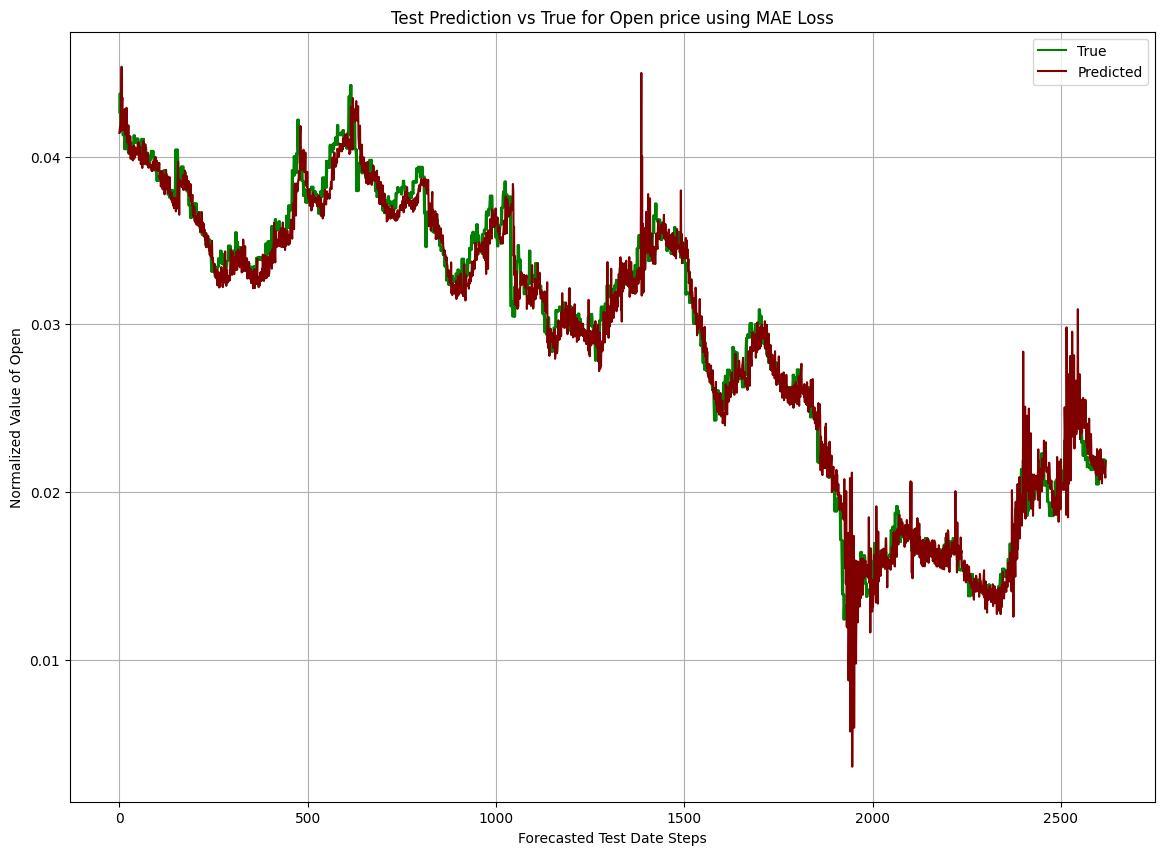

In [33]:
# MAE
PLOT_FEATURE = "Open" 

if PLOT_FEATURE not in feature_names:
    raise ValueError(f"{PLOT_FEATURE} not found. Choose from: {feature_names}")

feature_idx = feature_names.index(PLOT_FEATURE)

pred_feature = predictions_MAE[:, :, feature_idx].reshape(-1)
true_feature = targets_MAE[:, :, feature_idx].reshape(-1)

plt.figure(figsize=(14, 10))
plt.plot(true_feature, color='green', label="True")
plt.plot(pred_feature, color='maroon', label="Predicted")

plt.title(f"Test Prediction vs True for {PLOT_FEATURE} price using MAE Loss")
plt.xlabel("Forecasted Test Date Steps")
plt.ylabel(f"Normalized Value of {PLOT_FEATURE}")

plt.legend()
plt.grid(True)
plt.show()

### Plotting Predicted vs Target values of all 11 features for 5 days

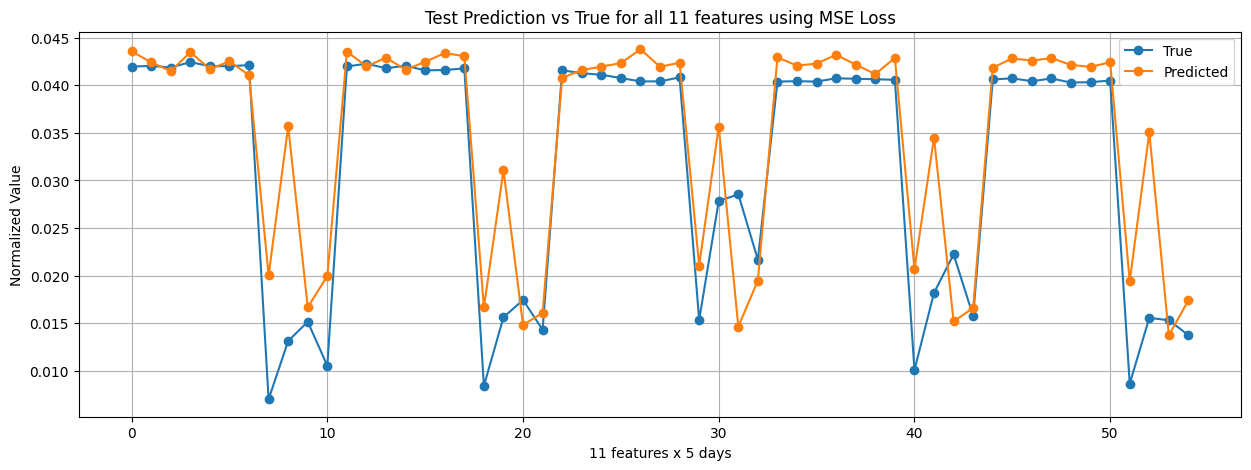

In [34]:
pred_feature = predictions_MSE[2, :, :].reshape(-1)
true_feature = targets_MSE[2, :, :].reshape(-1)

plt.figure(figsize=(15, 5))
plt.plot(true_feature, marker='o', label="True")
plt.plot(pred_feature,  marker='o', label="Predicted")

plt.title(f"Test Prediction vs True for all 11 features using MSE Loss")
plt.xlabel("11 features x 5 days")
plt.ylabel("Normalized Value")

plt.legend()
plt.grid(True)
plt.show()

### Performance Metrics (MSE, RMSE, MAE)

In [35]:
_, final_preds, final_targets = evaluate(model, test_loader, criterion_MSE,device)

preds_flat   = final_preds.reshape(-1)
targets_flat = final_targets.reshape(-1)

print(f"  MODEL    : Long Short Term Memory RNN Model")
print(f"  DATASET  : ONGC.csv (Roll No: 25MCA036)")
print(f"  INPUT    : {INPUT_STEPS} days → OUTPUT: {OUTPUT_STEPS} days")
print(f"  FEATURES : 11")
print("-+" * 30)
print(f"  MSE  (Mean Squared Error)       : {test_loss_MSE:.6f}")
print(f"  RMSE (Root Mean Squared Error)  : {test_loss_RMSE:.6f}")
print(f"  MAE  (Mean Absolute Error)      : {test_loss_MAE:.6f}")
print("-+" * 30)

print("\nPer-Feature Metrics:")
print(f"{'Feature':<25} {'MSE':>12} {'RMSE':>12} {'MAE':>12}")
print("-" * 66)
for i, feat in enumerate(feature_names):
    p = final_preds[:, :, i].reshape(-1)
    t = final_targets[:, :, i].reshape(-1)
    f_mse  = mean_squared_error(t, p)
    f_rmse = np.sqrt(f_mse)
    f_mae  = mean_absolute_error(t, p)
    print(f"{feat:<25} {f_mse:>12.6f} {f_rmse:>12.6f} {f_mae:>12.6f}")

  MODEL    : Long Short Term Memory RNN Model
  DATASET  : ONGC.csv (Roll No: 25MCA036)
  INPUT    : 10 days → OUTPUT: 5 days
  FEATURES : 11
-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+
  MSE  (Mean Squared Error)       : 0.000130
  RMSE (Root Mean Squared Error)  : 0.009150
  MAE  (Mean Absolute Error)      : 0.004532
-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+

Per-Feature Metrics:
Feature                            MSE         RMSE          MAE
------------------------------------------------------------------
Prev Close                    0.000002     0.001232     0.000843
Open                          0.000002     0.001404     0.000998
High                          0.000002     0.001283     0.000920
Low                           0.000002     0.001290     0.000920
Last                          0.000002     0.001570     0.001132
Close                         0.000002     0.001490     0.001083
VWAP                          0.000002     0.001384     0